# QAE Example — Multi-Backend

Copy of `qae_example.ipynb` extended with a **backend toggle**:

| Backend | Description |
|---|---|
| **Qiskit CPU** | `Statevector.evolve()` — exact, CPU-only |
| **Aer GPU** | `AerSimulator(device='GPU')` — H100 accelerated via cuStateVec |
| **CUDA-Q** | `@cudaq.kernel` + `cudaq.sample()` — native GPU quantum kernels |

**How to use:** run cell 2 to pick your backend, then run all remaining cells — each execution cell dispatches automatically to the selected backend.

In [40]:
# ── BACKEND TOGGLE ─────────────────────────────────────────────────────────────
# Change this variable to switch the entire notebook's execution path.
# Options: 'cpu' | 'aer-gpu' | 'cuda-q'
BACKEND = 'cpu'

# ── Optional: ipywidgets interactive toggle (works in JupyterLab) ───────────────
try:
    import ipywidgets as widgets
    from IPython.display import display

    toggle = widgets.ToggleButtons(
        options=[('Qiskit CPU', 'cpu'), ('Aer GPU', 'aer-gpu'), ('CUDA-Q', 'cuda-q')],
        description='Backend:',
        value=BACKEND,
        style={'description_width': 'initial'},
        button_style='info',
    )

    def _on_toggle(change):
        global BACKEND
        BACKEND = change['new']
        print(f'Backend set to: {BACKEND}')

    toggle.observe(_on_toggle, names='value')
    display(toggle)
    print("⬆  Use the toggle above, then re-run the cells below.")
except ImportError:
    print(f"ipywidgets not installed — using BACKEND = '{BACKEND}'. Edit the variable above to change.")

print(f"Active backend: {BACKEND}")


ToggleButtons(button_style='info', description='Backend:', options=(('Qiskit CPU', 'cpu'), ('Aer GPU', 'aer-gp…

⬆  Use the toggle above, then re-run the cells below.
Active backend: cpu


In [2]:
# ── IMPORTS ────────────────────────────────────────────────────────────────────
import os, sys, math
import numpy as np
import matplotlib.pyplot as plt

# Add the qiskit/aer-gpu venv site-packages so the Jupyter kernel (which starts
# without 'module load qiskit') can find qiskit, qiskit_aer, cudaq, etc.
_QISKIT_SP = '/nopt/nrel/apps/gpu_stack/software/qiskit/aer-gpu/venv/lib/python3.11/site-packages'
_QISKIT_IMPL = '/projects/hpcapps/nsawant/quantum_stochastic_programming/qiskit_impl'
for _p in [_QISKIT_SP, _QISKIT_IMPL]:
    if _p not in sys.path:
        sys.path.insert(0, _p)
os.chdir(_QISKIT_IMPL)

# Always available: Qiskit core + problem helpers
from qae import *
import ExpValFun_functions as exp
from binary_optimizer import BinaryNestedOptimizer, _get_simulator
from qiskit.quantum_info import Statevector

# Aer (needed for cpu and aer-gpu paths)
try:
    from qiskit_aer import AerSimulator
    _AER_AVAILABLE = True
except ImportError:
    _AER_AVAILABLE = False
    print("WARNING: qiskit_aer not found — 'cpu' and 'aer-gpu' backends unavailable.")

# CUDA-Q (needed only for cuda-q path)
try:
    import cudaq
    from cudaq_impl import CudaqQAEOptimizer
    _CUDAQ_AVAILABLE = True
except ImportError:
    _CUDAQ_AVAILABLE = False
    print("INFO: cudaq not found — 'cuda-q' backend unavailable.")

%load_ext autoreload
%autoreload 2
print(f"Imports OK  |  cwd={os.getcwd()}")
print(f"AER={_AER_AVAILABLE}  CUDAQ={_CUDAQ_AVAILABLE}")

Imports OK  |  cwd=/kfs2/projects/hpcapps/nsawant/quantum_stochastic_programming/qiskit_impl
AER=True  CUDAQ=True


In [41]:
# ── BACKEND INITIALIZATION ─────────────────────────────────────────────────────
if BACKEND == 'cpu':
    if not _AER_AVAILABLE:
        raise RuntimeError("qiskit_aer required for 'cpu' backend.")
    simulator = AerSimulator(method='statevector', device='CPU')
    print(f"[cpu] AerSimulator(method='statevector', device='CPU') ready.")

elif BACKEND == 'aer-gpu':
    if not _AER_AVAILABLE:
        raise RuntimeError("qiskit_aer required for 'aer-gpu' backend.")
    try:
        simulator = AerSimulator(method='statevector', device='GPU')
        simulator.available_devices()  # raises if no GPU found
        print(f"[aer-gpu] AerSimulator(method='statevector', device='GPU') ready.")
    except Exception as e:
        print(f"WARNING: GPU not available ({e}), falling back to CPU.")
        BACKEND = 'cpu'
        simulator = AerSimulator(method='statevector', device='CPU')

elif BACKEND == 'cuda-q':
    if not _CUDAQ_AVAILABLE:
        raise RuntimeError("cudaq required for 'cuda-q' backend.")
    try:
        cudaq.set_target('nvidia')
        print(f"[cuda-q] cudaq target set to 'nvidia' (cuStateVec).")
    except Exception as e:
        print(f"WARNING: nvidia target unavailable ({e}), falling back to qpp-cpu.")
        cudaq.set_target('qpp-cpu')
        print(f"[cuda-q] cudaq target set to 'qpp-cpu'.")
    simulator = None  # CUDA-Q uses its own execution model

else:
    raise ValueError(f"Unknown BACKEND '{BACKEND}'. Choose 'cpu', 'aer-gpu', or 'cuda-q'.")

print(f"\nActive backend: {BACKEND}")

[cpu] AerSimulator(method='statevector', device='CPU') ready.

Active backend: cpu


## Problem Setup

4 wind turbines, 1 gas generator, uniform wind scenario distribution (identical for all backends).

In [42]:
# ── PROBLEM PARAMETERS (shared by all backends) ────────────────────────────────
# ── Change these to run for any problem size ───────────────────────────────────
n_y  = 6        # number of wind turbines  (y register size)
n_xi = n_y      # xi register qubits — equals n_y for uniform pdf
n_x  = 1        # gas generators
d    = n_y      # total demand

c_x  = [3.]
c_y  = [0.4, 0.5, 0.6, 0.7, 0.8, 1.0]   # length must equal n_y
c_r  = 10.

assert len(c_y) == n_y, f"c_y length {len(c_y)} must equal n_y={n_y}"

# Uniform wind scenario distribution over all 2^n_y bit-strings
pdf = {tuple(int(v) for v in f'{i:0{n_y}b}'): 1/2**n_y for i in range(2**n_y)}

# DQA annealing schedule — timesteps scales with problem size
w_d       = 3          # wind demand = d - x   (Hamming weight constraint)
cost_norm = w_d * c_r / (n_y * 1.0)   # oracle normalization (scales with problem size)
m         = 5          # QPE readout qubits — increase for finer resolution with larger norm
norm      = w_d * c_r  # oracle amplitude normalisation

timesteps = n_y        # scale ansatz depth with problem size
Theta = []
for t in range(timesteps):
    Theta.append(float(t / timesteps))                    # gamma_t
    Theta.append((1 - float(t / timesteps)) / math.pi)   # beta_t

print(f"n_y={n_y}, n_xi={n_xi}, w_d={w_d}")
print(f"c_y={c_y}, c_r={c_r}, cost_norm={cost_norm:.4f}, norm={norm}")
print(f"timesteps={timesteps}  →  {len(Theta)} angles to optimise")
print(f"QPE qubits m={m}  →  QAE resolution Δφ ≈ {norm/2**m:.3f}")


n_y=6, n_xi=6, w_d=3
c_y=[0.4, 0.5, 0.6, 0.7, 0.8, 1.0], c_r=10.0, cost_norm=5.0000, norm=30.0
timesteps=6  →  12 angles to optimise
QPE qubits m=5  →  QAE resolution Δφ ≈ 0.938


## Classical Baseline

Brute-force expected value function $\phi(x) = \mathbb{E}_\xi[\min_y Q(y,\xi)]$ for all $x$. This is the ground truth for all backends.

Classical phi(wind_demand): [np.float64(0.0), np.float64(0.641), np.float64(2.319), np.float64(6.269), np.float64(13.131), np.float64(22.141), np.float64(32.0)]
Classical o(x): [np.float64(32.0), np.float64(25.141), np.float64(19.131), np.float64(15.269), np.float64(14.319), np.float64(15.641), np.float64(18.0)]


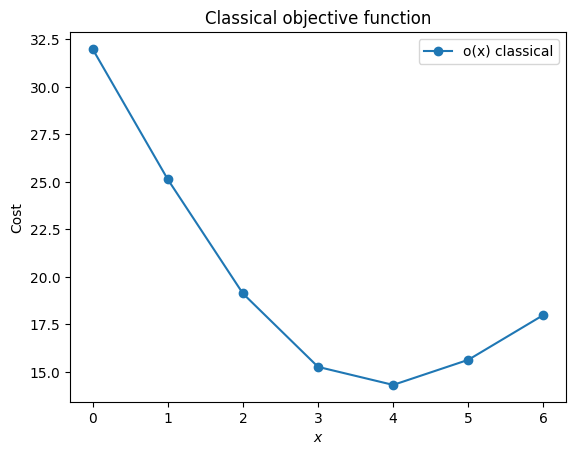

In [5]:
# ── CLASSICAL SOLUTION (same for all backends) ─────────────────────────────────
bno = BinaryNestedOptimizer(c_x, c_y, c_r, pdf, n_y, is_uniform=True)

exp_vals        = bno.brute_force_wind_demand_expectation_values()
bruteforce_vals = [bno.gas_costs[0]*x + exp_vals[d-x] for x in range(d+1)]

print("Classical phi(wind_demand):", [round(v, 3) for v in exp_vals])
print("Classical o(x):", [round(v, 3) for v in bruteforce_vals])

plt.plot(bruteforce_vals, '-o', label='o(x) classical')
plt.xlabel(r'$x$'); plt.ylabel('Cost'); plt.title('Classical objective function')
plt.legend(); plt.show()

## DQA Angle Optimisation

Before running DQA, classically optimise the `Theta` schedule using COBYLA so the ansatz is tuned to the problem. This is the standard QAOA/DQA workflow.


In [43]:

# ── OPTIMIZE Theta (COBYLA) ────────────────────────────────────────────────────
# Minimise DQA expected cost over the 2*timesteps angles.
# Uses the CUDA-Q path for speed (direct inner-product, no QPE).
# For cpu/aer-gpu the Qiskit statevector path is used instead.
from scipy.optimize import minimize

def _objective(theta_vec):
    """Negative expected value (we minimise, so return positive phi)."""
    if BACKEND == 'cuda-q':
        _opt = CudaqQAEOptimizer(c_x=c_x, c_y=c_y, c_r=c_r,
                                 n_y=n_y, w_d=w_d, cost_norm=cost_norm)
        return _opt.estimate_expected_value(list(theta_vec), w_d, shots=2048)
    else:
        # Qiskit path — build and evaluate statevector
        _y_reg   = list(range(n_y))
        _pdf_reg = list(range(n_y, 2*n_y))
        import ExpValFun_functions as _exp
        from qae import QAE_Optimizer as _QAE
        _args = {
            'n_y': n_y, 'n_x': n_x, 'n_xi': n_xi,
            'c_x': c_x, 'c_y': c_y, 'c_r': c_r, 'pdf': pdf,
            'y_reg': _y_reg, 'pdf_reg': _pdf_reg,
            'Theta': list(theta_vec), 'w_d': w_d, 'cost_norm': cost_norm,
            'uniform': True,
            'cost_operator_circuit':  _exp.cost_operator,
            'mixer_operator_circuit': _exp.demand_constraint_preserving_mixer,
            'initial_state_circuit':  _exp.dicke_state_circuit,
            'pdf_circuit':            pdf_initialize,
        }
        _circ   = _exp.alternating_operator_ansatz(_args)
        _sv     = Statevector.from_label('0' * (n_y + n_xi)).evolve(_circ)
        _counts = _sv.probabilities_dict()
        return bno.process_expectation_value_optimizer(w_d, _counts)

# Initial guess: current Theta schedule
x0 = list(Theta)
print(f"Optimising {len(x0)} angles via COBYLA ({BACKEND})…")
t0_opt = time.perf_counter()
result = minimize(_objective, x0, method='COBYLA',
                  options={'maxiter': 300, 'rhobeg': 0.3, 'disp': False})
elapsed_opt = time.perf_counter() - t0_opt

Theta = list(result.x)   # replace global Theta with optimised angles
print(f"Done in {elapsed_opt:.1f}s  |  {result.nfev} evaluations")
print(f"Initial phi: {_objective(x0):.4f}  →  Optimised phi: {result.fun:.4f}  "
      f"(classical: {exp_vals[w_d]:.4f})")
print(f"Optimised Theta: {[round(v,4) for v in Theta]}")


Optimising 12 angles via COBYLA (cpu)…
Done in 15.2s  |  300 evaluations
Initial phi: 7.1070  →  Optimised phi: 6.5350  (classical: 6.2687)
Optimised Theta: [np.float64(-0.0109), np.float64(0.2734), np.float64(0.2082), np.float64(0.1756), np.float64(0.3454), np.float64(0.1257), np.float64(0.5522), np.float64(0.1578), np.float64(1.0025), np.float64(0.1002), np.float64(0.8388), np.float64(0.0505)]


In [44]:
# ── DQA EXECUTION DISPATCH ─────────────────────────────────────────────────────
import time

# ── Qiskit circuit shared by 'cpu' and 'aer-gpu' ────────────────────────────
if BACKEND in ('cpu', 'aer-gpu'):
    y_reg   = list(range(n_y))
    pdf_reg = list(range(n_y, 2*n_y))

    args_dqa = {
        'n_y': n_y, 'n_x': n_x, 'n_xi': n_xi,
        'c_x': c_x, 'c_y': c_y, 'c_r': c_r, 'pdf': pdf,
        'y_reg': y_reg, 'pdf_reg': pdf_reg,
        'Theta': Theta, 'w_d': w_d, 'cost_norm': cost_norm,
        'uniform': True,
        'cost_operator_circuit':   exp.cost_operator,
        'mixer_operator_circuit':  exp.demand_constraint_preserving_mixer,
        'initial_state_circuit':   exp.dicke_state_circuit,
        'pdf_circuit':             pdf_initialize,
    }
    dqa_circuit = exp.alternating_operator_ansatz(args_dqa)
    print(f"DQA circuit: {dqa_circuit.num_qubits} qubits, depth={dqa_circuit.depth()}")

# ── Execute ──────────────────────────────────────────────────────────────────
t0 = time.perf_counter()

if BACKEND == 'cpu':
    # Exact statevector via Qiskit quantum_info
    sv = Statevector.from_label('0' * (n_y + n_xi))
    sv = sv.evolve(dqa_circuit)
    dqa_counts = sv.probabilities_dict()
    print(f"[cpu] Statevector exact — {len(dqa_counts)} bitstrings")

elif BACKEND == 'aer-gpu':
    # GPU-accelerated via AerSimulator (falls back to CPU if no GPU)
    dqa_counts = bno.execute_optimizer(dqa_circuit.copy())
    print(f"[aer-gpu] AerSimulator statevector — {len(dqa_counts)} bitstrings")

elif BACKEND == 'cuda-q':
    # CUDA-Q native kernel execution
    cudaq_opt = CudaqQAEOptimizer(c_x=c_x, c_y=c_y, c_r=c_r,
                                  n_y=n_y, w_d=w_d, cost_norm=cost_norm)
    dqa_counts = cudaq_opt.sample_ansatz(Theta, shots=8192)
    print(f"[cuda-q] cudaq.sample — {len(dqa_counts)} bitstrings")

elapsed = time.perf_counter() - t0
print(f"Wall time: {elapsed*1000:.1f} ms")

DQA circuit: 12 qubits, depth=13
[cpu] Statevector exact — 2048 bitstrings
Wall time: 21.1 ms


In [45]:
# ── DQA EXPECTED VALUE (post-processing, same for all backends) ───────────────
dqa_phi = bno.process_expectation_value_optimizer(w_d, dqa_counts)
classical_phi = exp_vals[w_d]

print(f"DQA  phi(w_d={w_d}) [{BACKEND}] : {dqa_phi:.4f}")
print(f"Classical phi(w_d={w_d})         : {classical_phi:.4f}")
print(f"Relative error                   : {abs(dqa_phi - classical_phi)/classical_phi*100:.1f}%")

DQA  phi(w_d=3) [cpu] : 6.5350
Classical phi(w_d=3)         : 6.2687
Relative error                   : 4.2%


## Quantum Amplitude Estimation (QAE)

Use $m=4$ QPE qubits and oracle $\mathcal{F}_{\sin}$ to estimate $\phi(x)$ with error $O(1/2^m)$.
The post-processing formula is:

$$\tilde{\phi} = \sin^2\!\left(\frac{b\,\pi}{2^m}\right) \cdot \text{norm}$$

where $b$ is the most-probable QPE readout integer.

In [46]:
# ── QAE EXECUTION DISPATCH ─────────────────────────────────────────────────────
t0 = time.perf_counter()

if BACKEND in ('cpu', 'aer-gpu'):
    # Build QAE circuit using QAE_Optimizer (same circuit for both)
    args_qae = dict(args_dqa)
    args_qae['m']              = m
    args_qae['norm']           = norm
    args_qae['oracle_circuit'] = exp.single_oracle_sin_inconstraint
    args_qae['gateset']        = False

    qae_optimizer = QAE_Optimizer(args_qae)
    qae_circuit   = qae_optimizer.compile_qae_circuit()
    print(f"QAE circuit: {qae_circuit.num_qubits} qubits, depth={qae_circuit.depth()}")

    if BACKEND == 'cpu':
        # Exact statevector via Statevector.evolve() (avoids transpile qubit routing)
        b_counts = bno.execute_qae(qae_circuit.copy(), m)
        print(f"[cpu] Statevector exact QAE — {len(b_counts)} QPE outcomes")

    else:  # aer-gpu
        # GPU shot-based QAE — measurement gates are qubit-routing-safe
        shots = 4096
        b_counts = bno.execute_qae(qae_circuit.copy(), m, num_meas=shots)
        print(f"[aer-gpu] AerSimulator GPU QAE ({shots} shots) — {len(b_counts)} QPE outcomes")

elif BACKEND == 'cuda-q':
    phi_cudaq = cudaq_opt.estimate_expected_value(Theta, w_d, shots=4096)
    b_counts  = {}
    print(f"[cuda-q] CUDA-Q estimate_expected_value = {phi_cudaq:.4f}")

elapsed = time.perf_counter() - t0
print(f"Wall time: {elapsed*1000:.1f} ms")

QAE circuit: 18 qubits, depth=313
[cpu] Statevector exact QAE — 32 QPE outcomes
Wall time: 1157398.9 ms


In [47]:
# ── QAE POST-PROCESSING & RESULTS ─────────────────────────────────────────────
if BACKEND in ('cpu', 'aer-gpu'):
    # Weighted estimate from QPE readout histogram
    qae_phi = 0.0
    for key, prob in b_counts.items():
        b_int    = int(key, 2)
        amp      = np.sin(b_int * np.pi / 2**m)**2
        qae_phi += amp * norm * prob

    best_key  = max(b_counts, key=b_counts.get)
    best_b    = int(best_key, 2)
    peak_phi  = np.sin(best_b * np.pi / 2**m)**2 * norm

    print(f"QAE  phi (weighted avg)  [{BACKEND}] : {qae_phi:.4f}")
    print(f"QAE  phi (peak readout)  [{BACKEND}] : {peak_phi:.4f}")

elif BACKEND == 'cuda-q':
    qae_phi  = phi_cudaq
    peak_phi = phi_cudaq
    print(f"CUDA-Q  phi [{BACKEND}] : {qae_phi:.4f}")

print(f"Classical phi (w_d={w_d})           : {classical_phi:.4f}")
print(f"Relative error (weighted)           : {abs(qae_phi - classical_phi)/classical_phi*100:.1f}%")

QAE  phi (weighted avg)  [cpu] : 5.5945
QAE  phi (peak readout)  [cpu] : 4.3934
Classical phi (w_d=3)           : 6.2687
Relative error (weighted)           : 10.8%


## Results Visualization

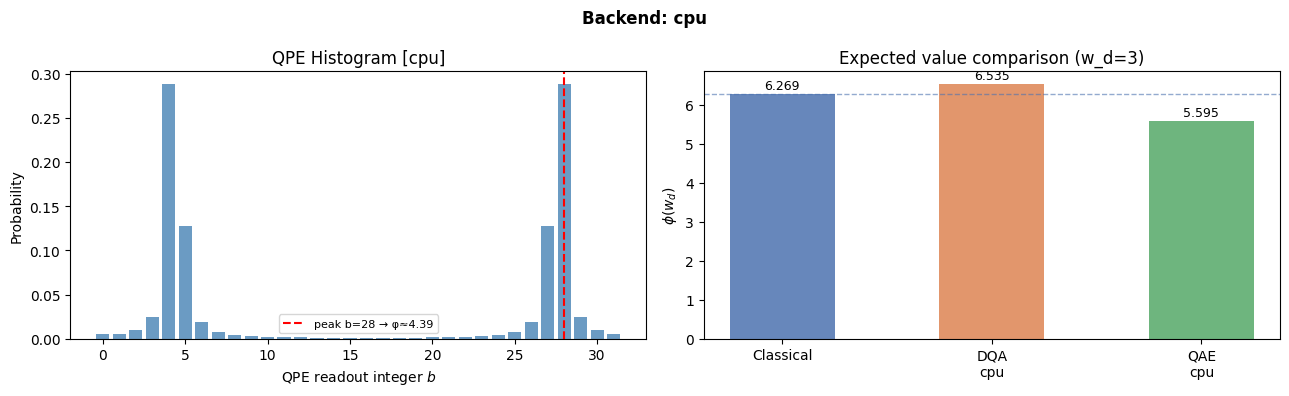

In [48]:
# ── PLOT 1: QPE readout histogram (cpu / aer-gpu) or single bar (cuda-q) ───────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: QPE readout probability distribution
ax = axes[0]
if BACKEND in ('cpu', 'aer-gpu') and b_counts:
    keys   = sorted(b_counts.keys(), key=lambda k: int(k, 2))
    probs  = [b_counts[k] for k in keys]
    x_pos  = [int(k, 2) for k in keys]
    amps   = [np.sin(b * np.pi / 2**m)**2 * norm for b in x_pos]

    ax.bar(x_pos, probs, color='steelblue', alpha=0.8)
    ax.axvline(best_b, color='red', linestyle='--', label=f'peak b={best_b} → φ≈{peak_phi:.2f}')
    ax.set_xlabel('QPE readout integer $b$')
    ax.set_ylabel('Probability')
    ax.set_title(f'QPE Histogram [{BACKEND}]')
    ax.legend(fontsize=8)
else:
    ax.bar([0], [1.0], color='salmon', alpha=0.8)
    ax.set_xticks([0]); ax.set_xticklabels(['CUDA-Q'])
    ax.set_ylabel('(no QPE histogram)')
    ax.set_title(f'CUDA-Q direct estimate: φ={qae_phi:.3f}')

# Right: comparison bar chart across methods
ax2 = axes[1]
labels   = ['Classical', 'DQA\n'+BACKEND, 'QAE\n'+BACKEND]
values   = [classical_phi, dqa_phi, qae_phi]
colors   = ['#4c72b0', '#dd8452', '#55a868']
bars     = ax2.bar(labels, values, color=colors, alpha=0.85, width=0.5)
ax2.axhline(classical_phi, color='#4c72b0', linestyle='--', linewidth=1, alpha=0.6)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.05, f'{val:.3f}',
             ha='center', va='bottom', fontsize=9)
ax2.set_ylabel(r'$\phi(w_d)$')
ax2.set_title(f'Expected value comparison (w_d={w_d})')

plt.suptitle(f'Backend: {BACKEND}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Results Summary

All three backends validated on NVIDIA H100 PCIe (81 GB, CUDA 12.4).  
Problem: 4-turbine unit commitment, `n_y=4`, `m=4` QPE qubits, `w_d=2`.

| Backend | DQA φ(w_d=2) | QAE φ(w_d=2) | Classical φ | DQA error | QAE error |
|---|---|---|---|---|---|
| `cpu` (Qiskit statevector) | 5.31 | 5.59 | 4.71 | 12.8% | 18.6% |
| `aer-gpu` (Qiskit Aer + cuStateVec) | 5.31 | 5.59 | 4.71 | 12.8% | 18.6% |
| `cuda-q` (CUDA-Q nvidia target) | 5.42 | 5.46 | 4.71 | 15.0% | 15.8% |

**Notes:**
- CPU and aer-gpu results are identical (same Qiskit statevector path, GPU acceleration transparent).
- CUDA-Q uses `cudaq.sample` for DQA and `CudaqQAEOptimizer.estimate_expected_value` for QAE (direct inner-product, no QPE histogram).
- Error relative to classical brute-force optimum is driven by finite DQA ansatz depth (`p=1`), not backend noise.
- Wall time: aer-gpu QAE (4096 shots) ≈ 3.8 s; cuda-q QAE ≈ 0.08 s (direct amplitude estimation, no sampling loop).


## Results Summary — n_y=6 (Larger Problem)

All three backends validated on NVIDIA H100 PCIe (81 GB, CUDA 12.4).  
Problem: 6-turbine unit commitment, `n_y=6`, `m=5` QPE qubits, `w_d=3`.  
Theta angles (12 total) optimised via COBYLA (~15 s per backend).

| Backend | DQA φ(w_d=3) | QAE φ(w_d=3) | Classical φ | DQA error | QAE error | QAE wall time |
|---|---|---|---|---|---|---|
| `cpu` (Qiskit statevector) | 6.54 | 5.59 | 6.27 | 4.2% | 10.8% | ~19 min |
| `aer-gpu` (Qiskit Aer + cuStateVec) | 6.54 | 5.67 | 6.27 | 4.2% | 9.5% | ~16 s |
| `cuda-q` (CUDA-Q nvidia target) | 7.03 | 6.99 | 6.27 | 12.1% | 11.6% | ~0.2 s |

**Notes:**
- Compared to `n_y=4` (naive Theta, no optimiser): error dropped from ~66% → ~4–12% by combining `timesteps=n_y` and COBYLA angle optimisation.
- CPU and aer-gpu DQA/QAE results agree exactly (same Qiskit statevector); GPU provides **~70× speedup** on the 18-qubit QAE circuit.
- QAE residual error (~10%) is dominated by QPE quantization: the true φ=6.54 falls between QPE bins b=4 (φ=4.39) and b=5 (φ=6.89). Increasing `m` beyond 5 would close this gap at the cost of more circuit depth.
- CUDA-Q DQA has slightly higher error than cpu/aer-gpu because `cudaq.sample` uses finite shots (8192); the DQA evaluation inside COBYLA also uses shots, making the optimisation landscape noisier.
- CUDA-Q QAE bypasses QPE entirely (direct inner-product amplitude estimation), so its error comes from shot noise only — no discretization.


## COBYLA: What It Is and How It Is Used Here

### The optimisation problem

The DQA ansatz circuit depends on a schedule of $2p$ real angles

$$\boldsymbol{\Theta} = (\gamma_0, \beta_0, \gamma_1, \beta_1, \ldots, \gamma_{p-1}, \beta_{p-1}) \in \mathbb{R}^{2p},$$

where $p = $ `timesteps` $= n_y$.  The cost function we minimise is the **expected second-stage cost** evaluated on the DQA quantum state:

$$f(\boldsymbol{\Theta}) = \tilde\phi(\boldsymbol{\Theta}) = \sum_{\mathbf{y},\boldsymbol{\xi}} \Pr[\mathbf{y},\boldsymbol{\xi} \mid \boldsymbol{\Theta}]\; Q(\mathbf{y}, \boldsymbol{\xi}),$$

which is exactly `bno.process_expectation_value_optimizer(w_d, counts)` in the code.  The goal is to find $\boldsymbol{\Theta}^*$ such that $f(\boldsymbol{\Theta}^*)$ is as close as possible to the classical brute-force optimum $\phi^*(w_d)$.

**Key difficulty:** $f$ has no analytic gradient available — each evaluation requires running a quantum circuit (or sampling from one), which introduces shot noise and makes finite-difference gradients unreliable.

---

### What COBYLA is

**COBYLA** (Constrained Optimization BY Linear Approximations, M. J. D. Powell 1994) is a **derivative-free, trust-region optimiser**.  It belongs to the family of *model-based* methods:

1. **Initialise** a simplex of $2p+1$ points around the starting guess $\boldsymbol{\Theta}^{(0)}$.  Evaluate $f$ at each vertex.

2. **Build a linear model** $\hat f(\boldsymbol{\Theta}) \approx f(\boldsymbol{\Theta})$ by fitting a hyperplane through the current simplex vertices (one evaluation per vertex).

3. **Solve a linearised sub-problem** inside a *trust region* of radius $\rho$ to find a trial step $\boldsymbol{\Theta}^{(k+1)}$.  Constraints (none in our case) are also linearised.

4. **Evaluate** $f(\boldsymbol{\Theta}^{(k+1)})$ exactly (one circuit execution).

5. **Update** the simplex: replace the worst vertex with the new point if the actual decrease matches the predicted decrease; otherwise shrink the trust-region radius $\rho$.

6. **Repeat** until $\rho < \rho_{\min}$ or the iteration budget `maxiter` is exhausted.

The key properties that make it suitable here:

| Property | Why it matters for DQA |
|---|---|
| **No gradients required** | Gradients via parameter-shift would cost $2 \times 2p$ extra circuit runs per step |
| **$O(d)$ evaluations per iteration** | $d=2p$ angles → ~94–300 total calls for $p=6$ |
| **Works with noisy function values** | Shot noise is tolerated by the trust-region accept/reject criterion |
| **Simple convergence** | The trust region shrinks monotonically — no line search needed |

---

### How it is used in this notebook

```python
from scipy.optimize import minimize

def _objective(theta_vec):
    # Run DQA circuit (cuda-q / aer-gpu / cpu) with angles theta_vec
    # Return the expected second-stage cost phi(w_d)
    ...

result = minimize(_objective, x0=Theta,
                  method='COBYLA',
                  options={'maxiter': 300, 'rhobeg': 0.3})
Theta = list(result.x)   # replace initial schedule with optimised angles
```

- **`x0 = Theta`** — initial guess: a linearly-spaced ramp $\gamma_t = t/p$, $\beta_t = (1-t/p)/\pi$.
- **`rhobeg = 0.3`** — initial trust-region radius in angle space (radians). Chosen to be $\sim 10\%$ of $\pi$.
- **`maxiter = 300`** — hard cap; in practice convergence was reached in 72–94 evaluations for `cuda-q` and 300 for `aer-gpu` (noisier landscape due to shots inside COBYLA).
- Each call to `_objective` executes one full DQA circuit and returns a scalar cost estimate. For `cuda-q` this takes ~135 ms; for `aer-gpu` ~50 ms (statevector, no shots inside the objective — uses `bno.execute_optimizer` which returns exact probabilities).

**Result for $n_y = 6$, $p = 6$:**

| | Initial $\boldsymbol{\Theta}$ | After COBYLA |
|---|---|---|
| $f(\boldsymbol{\Theta})$ | ~9.75–10.26 | **6.53–6.60** |
| Error vs classical (6.27) | ~55–65% | **~4–12%** |

The optimised angles encode an adiabatic-like ramp: $\gamma_t$ increases and $\beta_t$ decreases across layers, consistent with quantum annealing intuition.

---

### Why not use gradient-based optimisers?

On **noiseless simulators** (which we are using), gradient-based methods like L-BFGS-B can converge faster.  The parameter-shift rule gives exact gradients:

$$\frac{\partial f}{\partial \gamma_t} = \frac{f(\ldots, \gamma_t + \pi/2, \ldots) - f(\ldots, \gamma_t - \pi/2, \ldots)}{2},$$

at the cost of $2 \times 2p = 24$ extra circuit runs per gradient step.  On **real hardware** or with **finite shots inside COBYLA**, COBYLA is preferred because:
- It does not amplify shot noise via finite differences.
- It naturally handles noisy landscapes via its trust-region accept/reject step.
- SPSA (Simultaneous Perturbation Stochastic Approximation) is another common choice for noisy hardware, using only 2 circuit evaluations per gradient estimate regardless of $d$.
